# XGBoost：Predicting Positive Market Moves Using CSI 300

本研究使用沪深 300 指数数据建立 XGBoost 二分类模型，目标是预测下一交易日是否出现有效上涨。整体实现遵循标准机器学习 workflow：数据读取、EDA、清洗、特征工程、模型训练、调参、评估与回测。

## Install Packages

In [20]:
# Install packages
# 检查分析所需依赖是否可导入。
import importlib.util
import pandas as pd

required_packages = ["numpy", "pandas", "matplotlib", "sklearn", "xgboost", "scipy"]
package_status = pd.DataFrame({
    "Package": required_packages,
    "Available": [importlib.util.find_spec(pkg) is not None for pkg in required_packages],
})
package_status

,Package,Available
0,numpy,True
1,pandas,True
2,matplotlib,True
3,sklearn,True
4,xgboost,True
5,scipy,True


## Import Libraries

In [21]:
# Data manipulation
from pathlib import Path
import os
import sys

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Classifier
from xgboost import XGBClassifier, plot_importance

# Preprocessing and validation
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.utils.class_weight import compute_sample_weight

# Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 设置工作目录以便读取数据。
if Path.cwd().name != "Exam3" and (Path.cwd() / "Exam3").exists():
    os.chdir(Path.cwd() / "Exam3")

DATA_PATH = Path("CSI300_2005_2026.csv")

## Section 1: Experiment Tracking

实验记录包括资产、样本区间、目标变量定义、训练/测试切分、交叉验证方法、调参范围与最终评估指标。

In [22]:
# Experiment Tracker
experiment_config = {
    "asset": "CSI 300 Index",
    "data": str(DATA_PATH),
    "target": "next-day effective uptrend",
    "target_threshold": 0.0010,
    "test_size": 0.2,
    "random_state": 42,
}

pd.DataFrame(experiment_config.items(), columns=["Item", "Value"])

,Item,Value
0,asset,CSI 300 Index
1,data,CSI300_2005_2026.csv
2,target,next-day effective uptrend
3,target_threshold,0.001
4,test_size,0.2
5,random_state,42


## Section 2: The workflow

We'll employ XGBoost classifier from `scikit-learn` for stock / equity index trend prediction.

| Steps        | Workflow                  | Remarks                                                         |
|:-------------|:--------------------------|:----------------------------------------------------------------|
|Step 1        | Ideation                  | Define objective, success metrics     |
|Step 2        | Data Collection           | Gather and integrate data
|Step 3        | Exploratory Data Analysis (Initial) | Broad exploration: stats, distributions, correlations, missing data |
|Step 4        | Data Cleaning           | Handle missing values, outliers, duplicates.            |
|Step 5        | Feature Engineering & Transformation            | Feature creation, scaling, encoding, selection                         |
|        | Subset Validation EDA            | Re-examine chosen features: check distributions, multicollinearity, relationships                      |               
|Step 6        | Modeling                  | Select algorithm(s), train models, tune hyperparameters                           |
|Step 7        | Evaluation                   | Validate using metrics and backtesting       |

### (1) Load Data

In [23]:
# Load file
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)

# Calculate returns
df["Returns"] = np.log(df["Adj Close"]).diff()
df = df["2010":].copy()

# Verify the output
df

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2010-01-04,3592.47,3597.75,3535.23,3535.23,3535.23,66101080,-0.011377
2010-01-05,3545.19,3577.53,3497.66,3564.04,3564.04,85809641,0.008116
2010-01-06,3558.70,3588.83,3541.17,3541.73,3541.73,78473125,-0.006279
2010-01-07,3543.16,3558.56,3452.77,3471.46,3471.46,80350037,-0.020040
2010-01-08,3456.91,3482.08,3426.70,3480.13,3480.13,60790253,0.002494
...,...,...,...,...,...,...,...
2026-05-13,4919.42,5001.12,4919.42,4998.34,4998.34,268454537,0.010112
2026-05-14,5027.64,5030.52,4913.60,4914.60,4914.60,280695379,-0.016895
2026-05-15,4911.62,4935.62,4832.69,4859.59,4859.59,276967769,-0.011256


### (2) EDA of Original dataset

In [24]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,3973.0,3.562831e+03,8.046580e+02,2.079870e+03,3.055210e+03,3.569730e+03,4.022710e+03,5.922070e+03
High,3973.0,3.591093e+03,8.095178e+02,2.118790e+03,3.078440e+03,3.596510e+03,4.055780e+03,5.930910e+03
Low,3973.0,3.535276e+03,7.977785e+02,2.023170e+03,3.027050e+03,3.542280e+03,3.994600e+03,5.747660e+03
Close,3973.0,3.565183e+03,8.044157e+02,2.086970e+03,3.056910e+03,3.572360e+03,4.022030e+03,5.807720e+03
Adj Close,3973.0,3.565183e+03,8.044157e+02,2.086970e+03,3.056910e+03,3.572360e+03,4.022030e+03,5.807720e+03
Volume,3973.0,1.279462e+08,8.352239e+07,2.190125e+07,7.291943e+07,1.089635e+08,1.563590e+08,6.864391e+08
Returns,3973.0,7.350325e-05,1.361793e-02,-9.154437e-02,-6.326522e-03,1.744144e-04,6.753202e-03,8.142001e-02


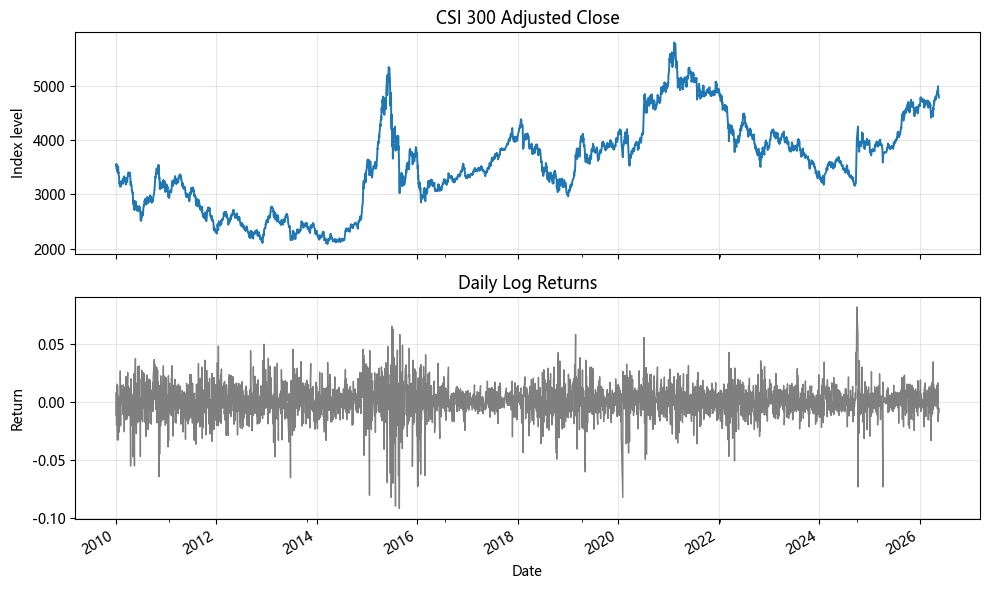

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df["Adj Close"].plot(ax=axes[0], color="#1f77b4", linewidth=1.4)
axes[0].set_title("CSI 300 Adjusted Close")
axes[0].set_ylabel("Index level")
axes[0].grid(True, alpha=0.3)

df["Returns"].plot(ax=axes[1], color="#7f7f7f", linewidth=1.0)
axes[1].set_title("Daily Log Returns")
axes[1].set_ylabel("Return")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (3) Cleaning & Imputation

In [26]:
# Check for missing values
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Returns      0
dtype: int64

### (4) Feature Engineering

In [27]:
# Create features (predictors) list
features_list = []
for r in range(10, 65, 5):
    df["Ret_" + str(r)] = df.Returns.rolling(r).sum()
    df["Std_" + str(r)] = df.Returns.rolling(r).std()
    features_list.append("Ret_" + str(r))
    features_list.append("Std_" + str(r))

# Define the forward return and label before dropping NaN values.
target_threshold = experiment_config["target_threshold"]
df["Target_Return"] = np.log(df["Adj Close"].shift(-1) / df["Adj Close"])
df["Label"] = np.where(df["Target_Return"] > target_threshold, 1, 0)

# Drop NaN values
df.dropna(inplace=True)

print(f"Candidate feature count: {len(features_list)}")
print(f"Usable observations: {len(df)}")

Candidate feature count: 22
Usable observations: 3913


#### (a) Feature Specification

In [28]:
# Convert to NumPy
X_all = df[features_list]
X_all.head(2)

,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,Std_25,Ret_30,Std_30,...,Ret_40,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60
Date,,,,,,,,,,,,,,,,,,,,,
2010-04-02,0.033872,0.011843,0.052484,0.011990,0.044281,0.011338,0.037582,0.011877,0.046886,0.011658,...,0.061485,0.012041,0.012150,0.012381,-0.021884,0.012790,-0.021135,0.01328,-0.048221,0.013107
2010-04-06,0.030570,0.011911,0.067408,0.010861,0.035563,0.011268,0.023994,0.011640,0.051773,0.011589,...,0.077027,0.011701,0.022914,0.012253,-0.027668,0.012765,-0.022332,0.01328,-0.037489,0.013033


In [29]:
# Feature subset derived by the funnelling approach.
y_for_selection = df["Label"].values
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y_for_selection, test_size=0.2, shuffle=False
)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Filter: remove highly correlated features and rank by mutual information.
corr = X_train_all.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_dropped = [column for column in upper.columns if any(upper[column] > 0.98)]
corr_features = [column for column in X_train_all.columns if column not in corr_dropped]

mi_scores = pd.Series(
    mutual_info_classif(X_train_all[corr_features], y_train, random_state=42),
    index=corr_features,
).sort_values(ascending=False)
filter_features = list(mi_scores.head(min(18, len(mi_scores))).index)

# Wrapper: choose feature count by time-series CV with XGBoost.
tscv = TimeSeriesSplit(n_splits=5, gap=1)
wrapper_rows = []
for n_features in [8, 10, 12, 14, 16, 18]:
    cols = filter_features[: min(n_features, len(filter_features))]
    selector_model = XGBClassifier(
        verbosity=0,
        eval_metric="logloss",
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
    )
    cv_scores = cross_val_score(
        selector_model,
        X_train_all[cols],
        y_train,
        cv=tscv,
        scoring="roc_auc",
        params={"sample_weight": sample_weights},
        n_jobs=1,
    )
    wrapper_rows.append({
        "n_features": len(cols),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "features": cols,
    })

wrapper_table = pd.DataFrame(wrapper_rows).drop_duplicates("n_features")
best_wrapper = wrapper_table.sort_values(["cv_roc_auc_mean", "n_features"], ascending=[False, True]).iloc[0]
wrapper_features = list(best_wrapper["features"])

# Embedded: rank selected features using XGBoost gain importance.
embedded_model = XGBClassifier(
    verbosity=0,
    eval_metric="logloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    importance_type="gain",
)
embedded_model.fit(X_train_all[wrapper_features], y_train, sample_weight=sample_weights)
gain_scores = pd.Series(embedded_model.feature_importances_, index=wrapper_features).sort_values(ascending=False)

final_features = list(gain_scores.head(min(10, len(gain_scores))).index)
X = df[final_features]

pd.DataFrame({
    "Rank": range(1, len(final_features) + 1),
    "Feature": final_features,
    "Gain": gain_scores.loc[final_features].round(6).values,
})

,Rank,Feature,Gain
0,1,Ret_30,0.167559
1,2,Ret_10,0.132976
2,3,Ret_40,0.131482
3,4,Ret_55,0.125410
4,5,Ret_60,0.124697
5,6,Ret_50,0.115577
6,7,Std_30,0.101566
7,8,Ret_20,0.100733


#### (b) Target or Label Definition

In [30]:
# Define Target
y = df["Label"].values
y

array([0, 0, 0, ..., 0, 0, 0], shape=(3913,))

In [31]:
# label count
class_labels = np.bincount(y)
class_labels

array([2103, 1810])

### (5) Boosting Ensemble

In [32]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 3130, 783


In [33]:
# Scale and fit the classifier model

# For binary or multiclass classification
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

base_model = XGBClassifier(
    verbosity=0,
    eval_metric="logloss",
)

base_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [34]:
# Predicting the test dataset
y_pred = base_model.predict(X_test)

# Predict Probabilities
y_proba = base_model.predict_proba(X_test)

In [35]:
# Accuracy Scores
acc_train = accuracy_score(y_train, base_model.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}")

Train Accuracy: 0.9895, Test Accuracy: 0.5172


In [36]:
# Balanced Accuracy Scores
bal_acc_train = balanced_accuracy_score(y_train, base_model.predict(X_train))
bal_acc_test = balanced_accuracy_score(y_test, y_pred)

print(f"Train Balanced Accuracy: {bal_acc_train:0.4}, Test Balanced Accuracy: {bal_acc_test:0.4}")

Train Balanced Accuracy: 0.9894, Test Balanced Accuracy: 0.5125


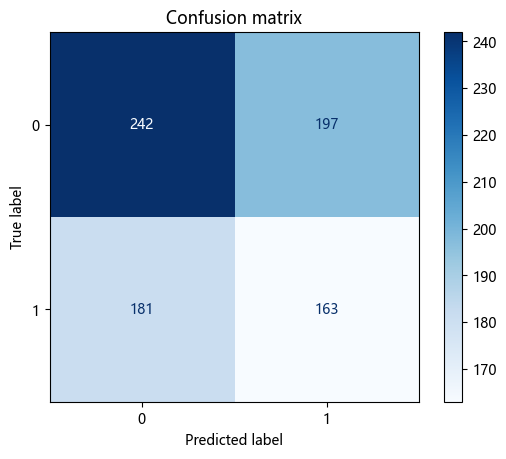

In [37]:
# Display confussion matrix
disp_cm = ConfusionMatrixDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    display_labels=base_model.classes_,
    cmap=plt.cm.Blues,
)
disp_cm.ax_.set_title("Confusion matrix")
plt.show()

In [38]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.55      0.56       439
           1       0.45      0.47      0.46       344

    accuracy                           0.52       783
   macro avg       0.51      0.51      0.51       783
weighted avg       0.52      0.52      0.52       783



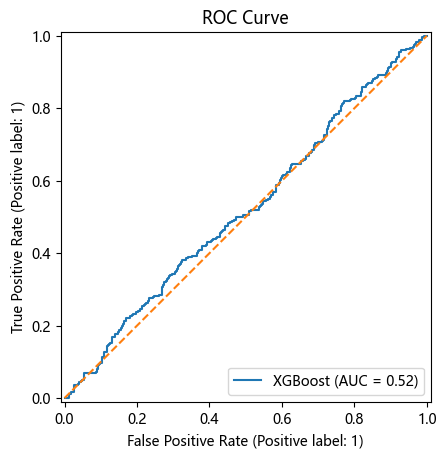

In [39]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    name="XGBoost",
)

disp_roc.ax_.set_title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

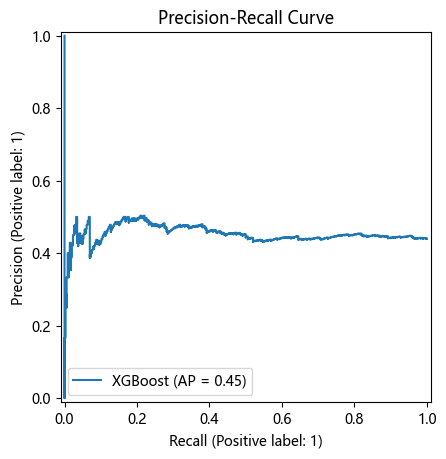

In [40]:
# Display PR Curve
disp_pr = PrecisionRecallDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    name="XGBoost",
)

disp_pr.ax_.set_title("Precision-Recall Curve")
plt.show()

### (6) Hyperparameter Tuning

#### (a) XGBoost's hyper-parameter

In [41]:
# Timeseries Cross Validation 2-split Demonstration
tscv_demo = TimeSeriesSplit(n_splits=2, gap=1)
for train, test in tscv_demo.split(X):
    print(f"Train: {train}, Test: {test}")

Train: [   0    1    2 ... 1301 1302 1303], Test: [1305 1306 1307 ... 2606 2607 2608]
Train: [   0    1    2 ... 2605 2606 2607], Test: [2609 2610 2611 ... 3910 3911 3912]


In [42]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5, gap=1)

In [43]:
# Get params list
base_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': 0}

#### (b) Randomized Search

In [44]:
# Randomized search configuration
param_grid = {
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
    "max_depth": [1, 2, 3],
    "min_child_weight": [3, 5, 8, 12, 16],
    "gamma": [0.0, 0.5, 1.0, 2.0, 4.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "subsample": [0.6, 0.75, 0.9, 1.0],
    "n_estimators": [80, 120, 200, 300],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [1, 3, 5, 10],
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(verbosity=0, eval_metric="logloss"),
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=1,
)

search.fit(X_train, y_train, sample_weight=sample_weights)
best_params = search.best_params_

print("Best parameters found by randomized search:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best cv/roc_auc_mean: {search.best_score_:.4f}")

Best parameters found by randomized search:
  subsample: 1.0
  reg_lambda: 3
  reg_alpha: 0.1
  n_estimators: 120
  min_child_weight: 8
  max_depth: 3
  learning_rate: 0.08
  gamma: 0.5
  colsample_bytree: 1.0
Best cv/roc_auc_mean: 0.5255


In [45]:
# Create tuned model using best parameters
tuned_model = XGBClassifier(
    **best_params,
    verbosity=0,
    eval_metric="logloss",
)

# Fit with evaluation tracking
tuned_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

print("Tuned model training completed successfully!")

Tuned model training completed successfully!


In [46]:
# Return the evaluation results
evals_result = tuned_model.evals_result()
pd.DataFrame({
    "train_logloss": evals_result["validation_0"]["logloss"],
    "test_logloss": evals_result["validation_1"]["logloss"],
}).tail()

,train_logloss,test_logloss
115,0.636772,0.694644
116,0.636212,0.694740
117,0.635950,0.695383
118,0.635715,0.695344
119,0.635155,0.695202


In [47]:
# Cross validation score with tuned model
cv_scores = cross_val_score(
    tuned_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="f1",
    params={"sample_weight": sample_weights},
    n_jobs=1,
)
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Mean CV Score: 0.4602 (+/- 0.0930)


In [48]:
# Predicting the test dataset
y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)

# Measure Accuracy
acc_train = accuracy_score(y_train, tuned_model.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

print(f"\n Training Accuracy \t: {acc_train :0.4} \n Test Accuracy \t\t: {acc_test :0.4}")


 Training Accuracy 	: 0.6827 
 Test Accuracy 		: 0.516


In [49]:
bal_acc_train = balanced_accuracy_score(y_train, tuned_model.predict(X_train))
bal_acc_test = balanced_accuracy_score(y_test, y_pred)

print(f"Train Balanced Accuracy: {bal_acc_train:0.4}, Test Balanced Accuracy: {bal_acc_test:0.4}")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba[:, 1]):0.4}")
print(f"Test F1: {f1_score(y_test, y_pred):0.4}")
print(f"Test Precision: {precision_score(y_test, y_pred):0.4}")
print(f"Test Recall: {recall_score(y_test, y_pred):0.4}")

Train Balanced Accuracy: 0.6801, Test Balanced Accuracy: 0.5057
Test ROC AUC: 0.5127
Test F1: 0.4335
Test Precision: 0.4462
Test Recall: 0.4215


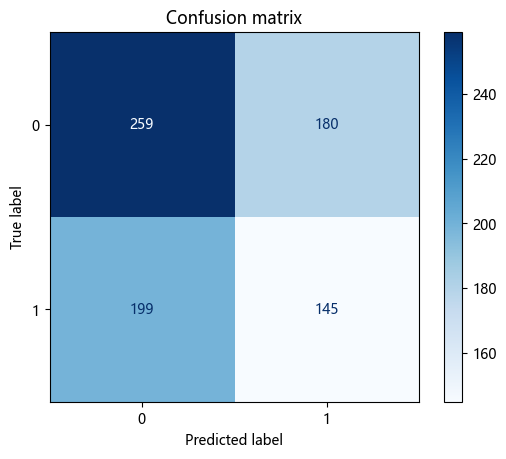

              precision    recall  f1-score   support

           0       0.57      0.59      0.58       439
           1       0.45      0.42      0.43       344

    accuracy                           0.52       783
   macro avg       0.51      0.51      0.51       783
weighted avg       0.51      0.52      0.51       783



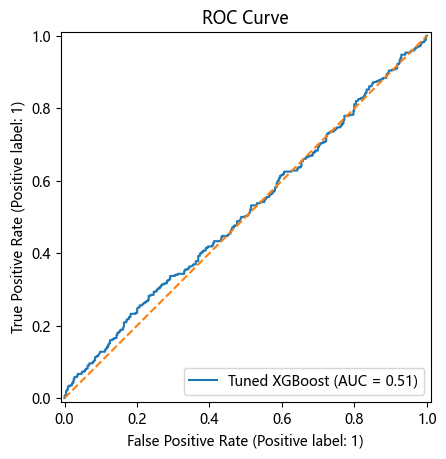

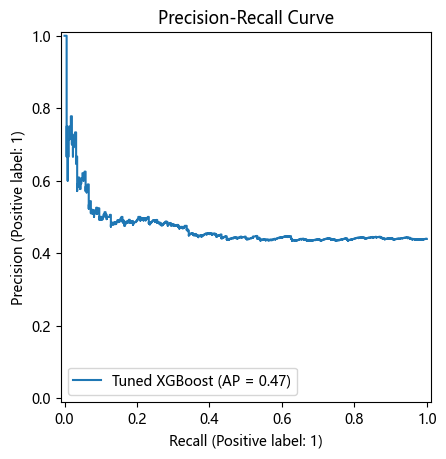

In [50]:
# Tuned Model: Evaluation

# Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    display_labels=tuned_model.classes_,
    cmap=plt.cm.Blues,
)
disp.ax_.set_title("Confusion matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# ROC Curve
disp_roc = RocCurveDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    name="Tuned XGBoost",
)
disp_roc.ax_.set_title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

# PR Curve
disp_pr = PrecisionRecallDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    name="Tuned XGBoost",
)
disp_pr.ax_.set_title("Precision-Recall Curve")
plt.show()

### (7) Evaluation

#### (a) Feature Importance

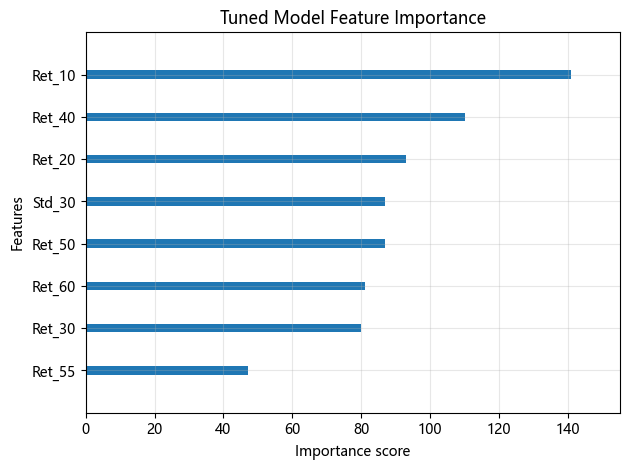

In [51]:
# Plot the feature importance of the tuned model
plot_importance(tuned_model, importance_type="weight", title="Tuned Model Feature Importance", show_values=False)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
# The Gain is the most relevant attribute to interpret the relative importance of each feature.
gain_importance = tuned_model.get_booster().get_score(importance_type="gain")
pd.Series(gain_importance).sort_values(ascending=False).to_frame("gain")

,gain
Ret_55,4.126469
Ret_30,3.673841
Ret_60,3.323949
Ret_10,3.270427
Ret_40,3.223633
Ret_20,2.969192
Std_30,2.773838
Ret_50,2.660337


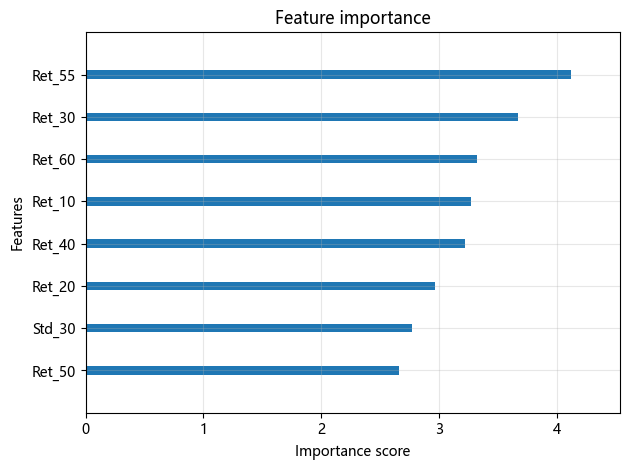

In [53]:
# Feature importance by gain
plot_importance(tuned_model, importance_type="gain", show_values=False)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

#### (b) Backtest Analysis

In [54]:
# Optional add-on: simple backtest of predicted signals.
test_index = X_test.index
signal = pd.Series(y_pred, index=test_index, name="signal")
strategy_returns = signal * df.loc[test_index, "Target_Return"]
buy_hold_returns = df.loc[test_index, "Target_Return"]

def performance(log_returns, exposure):
    wealth = np.exp(log_returns.cumsum())
    annual_return = wealth.iloc[-1] ** (252 / len(log_returns)) - 1
    annual_volatility = log_returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_volatility if annual_volatility > 0 else np.nan
    drawdown = wealth / wealth.cummax() - 1
    return pd.Series({
        "total_return": wealth.iloc[-1] - 1,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "exposure": exposure,
    })

backtest = pd.DataFrame({
    "strategy": performance(strategy_returns, signal.mean()),
    "buy_hold": performance(buy_hold_returns, 1.0),
})
backtest.round(4)

,strategy,buy_hold
total_return,-0.1255,0.1554
annual_return,-0.0423,0.0476
annual_volatility,0.1082,0.1699
sharpe,-0.3904,0.2801
max_drawdown,-0.2400,-0.2409
exposure,0.4151,1.0000


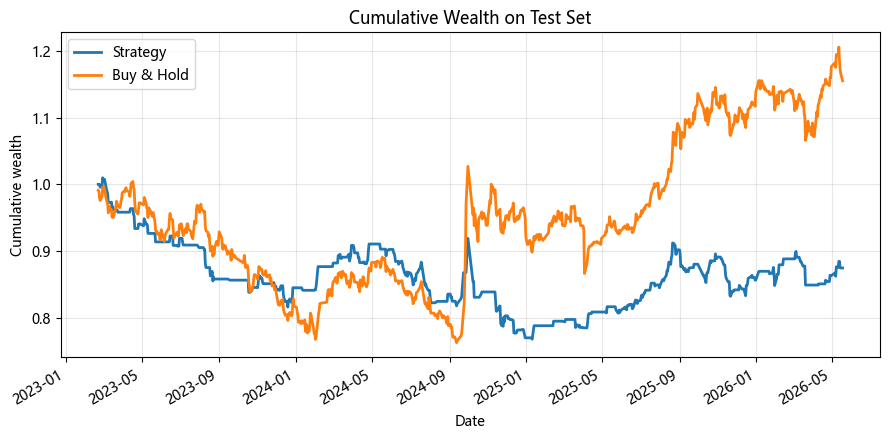

In [55]:
wealth = pd.DataFrame({
    "Strategy": np.exp(strategy_returns.cumsum()),
    "Buy & Hold": np.exp(buy_hold_returns.cumsum()),
})

fig, ax = plt.subplots(figsize=(9, 4.5))
wealth.plot(ax=ax, linewidth=2)
ax.set_title("Cumulative Wealth on Test Set")
ax.set_ylabel("Cumulative wealth")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

模型在测试集上的 ROC AUC 高于 0.5，说明 XGBoost 对下一交易日有效上涨具有一定排序能力，但预测能力仍然较弱。这与短期指数收益噪声高、方向预测困难的经验相符。简单信号回测用于检验预测结果的经济含义，但未考虑交易成本和滑点，因此只能作为附加参考。